In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation as R
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep
from ur_ikfast.ur_ikfast import ur_kinematics

In [2]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [3]:
zarr_path = '/home/soochul/GoPro_20250304/dataset.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")
episode_idx = np.random.choice(num_episodes)
print(f"Replaying episode {episode_idx}...")
ep = replay_buffer.get_episode(episode_idx)
# print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])
for robot_idx in range(1):
    pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
    rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
    grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

Loaded replay buffer with 65 episodes.
Replaying episode 52...


In [4]:
cam_pose = np.concatenate([pos_replay, rot_replay], axis=-1)
cam_pose = pose_to_mat(cam_pose)
cam_pose.shape

(1239, 4, 4)

In [5]:
tx_tag_tcp = cam_pose

In [6]:
tx_tag_base = np.array([
        [
      -0.9992668101498986,
      0.03786236221936187,
      0.005681871172127269,
      -0.018283582081895254
    ],
    [
      -0.03760656116820821,
      -0.998497334760624,
      0.03985999288801041,
      -0.49712673959771314
    ],
    [
      0.007182526710609295,
      0.03961709231001545,
      0.9991891198901993,
      -0.042018964151028
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  
  ])

tx_base_tag = np.linalg.inv(tx_tag_base)

In [7]:
tx_base_tcp = tx_base_tag @ tx_tag_tcp

In [8]:
base_tcp_pose = mat_to_pose(tx_base_tcp)

In [9]:
base_tcp_pose.shape

(1239, 6)

In [10]:
tx_base_tcp[0]

array([[-0.99724304,  0.00628556,  0.07393826, -0.04836606],
       [-0.0665739 ,  0.36432809, -0.92888802, -0.29252488],
       [-0.03277637, -0.93124946, -0.3629052 ,  0.30977635],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [11]:
ur3_arm = ur_kinematics.URKinematics('ur3')

joint_angles = [-3.1, -1.6, 1.6, -1.6, -1.6, 0.]  # in radians
print("joint angles", joint_angles)

pose_quat = ur3_arm.forward(joint_angles)
pose_matrix = ur3_arm.forward(joint_angles, 'matrix')

print("forward() quaternion \n", pose_quat)
print("forward() matrix \n", pose_matrix)

print("inverse() one from quat", ur3_arm.inverse(pose_quat, False, q_guess=joint_angles))

print("inverse() one from matrix", ur3_arm.inverse(pose_matrix, False, q_guess=joint_angles))


joint angles [-3.1, -1.6, 1.6, -1.6, -1.6, 0.0]
forward() quaternion 
 [-0.28901327 -0.12208153  0.31610811 -0.69627027 -0.02465703  0.71734233
 -0.00444365]
forward() matrix 
 [[-0.03037599  0.04071115 -0.99870914 -0.28901327]
 [ 0.02796067 -0.99874455 -0.04156303 -0.12208153]
 [-0.99914742 -0.0291871   0.02919955  0.31610811]]
inverse() one from quat [-3.09999990e+00 -1.60000002e+00  1.60000002e+00 -1.59999990e+00
 -1.60000002e+00  8.12307910e-09]
inverse() one from matrix [-3.09999990e+00 -1.60000002e+00  1.60000002e+00 -1.60000002e+00
 -1.60000002e+00  3.58920644e-08]


In [12]:
num_ur3_joints = 6
ep_length = tx_base_tcp.shape[0]
timesteps = np.arange(ep_length)

joint_trajectory = np.zeros((ep_length, num_ur3_joints))

for t, pose in enumerate(tx_base_tcp):
    curr_pose = pose[:3, :4]
    if t != 0:
        joint_trajectory[t, :] = ur3_arm.inverse(curr_pose, False, q_guess=joint_trajectory[t-1, :])
    else:
        joint_trajectory[t, :] = ur3_arm.inverse(curr_pose, False)

joint_trajectory.shape

(1239, 6)

In [42]:
type(joint_trajectory[2])

numpy.ndarray

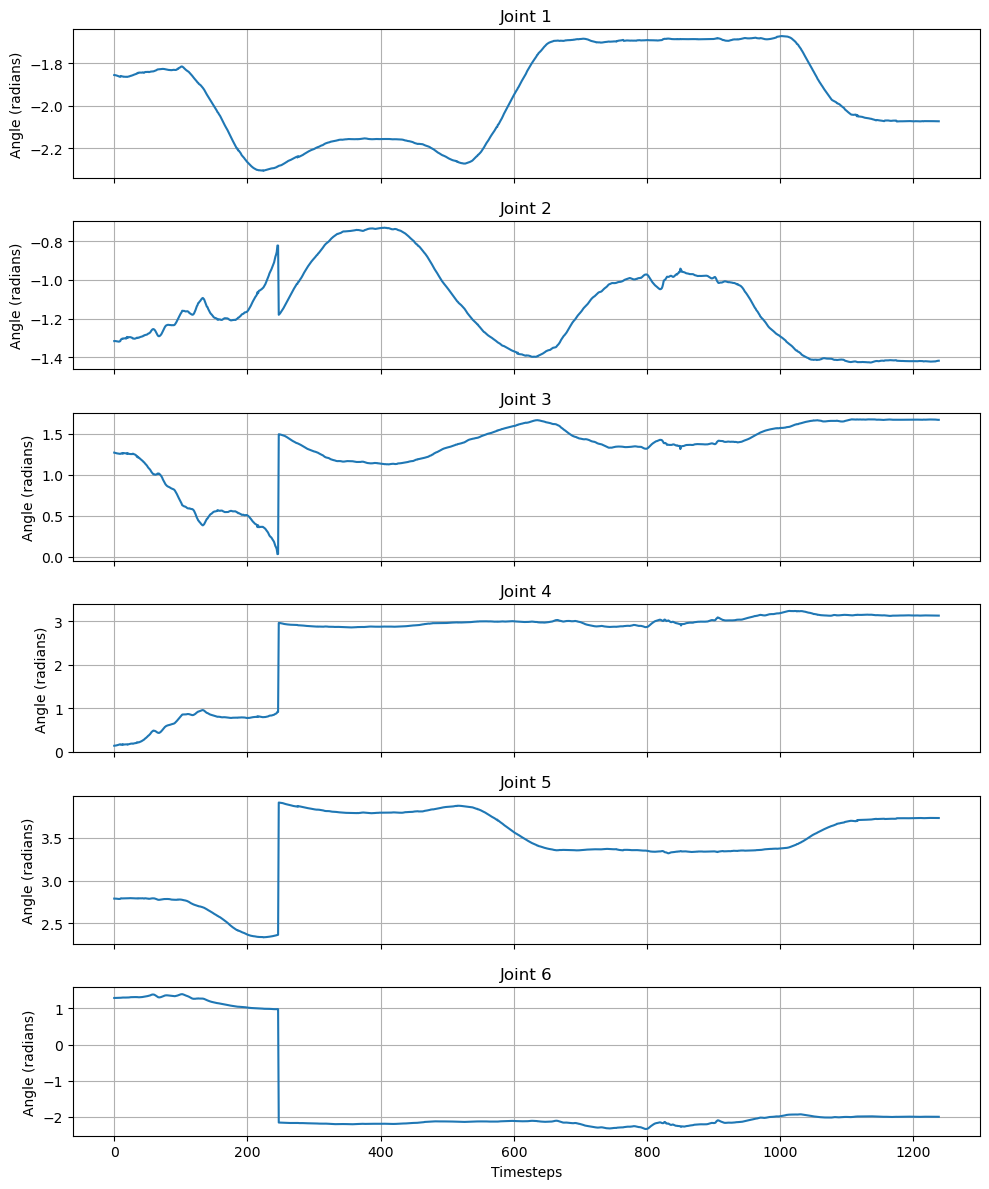

In [14]:
fig, axs = plt.subplots(num_ur3_joints, 1, figsize=(10, 2 * num_ur3_joints), sharex=True)

for joint in range(num_ur3_joints):
    axs[joint].plot(timesteps, joint_trajectory[:, joint], linestyle='-')
    axs[joint].set_title(f'Joint {joint + 1}')
    axs[joint].set_ylabel('Angle (radians)')
    axs[joint].grid(True)

axs[-1].set_xlabel('Timesteps')
plt.tight_layout()
plt.show()

In [ ]:
def add_traces(fig, T, scale=0.05, marker_color='black', marker_size=2):
    origin = T[:3, 3]
    R = T[:3, :3]
    fig.add_trace(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers',
        marker=dict(size=marker_size, color=marker_color),
        showlegend=False
    ))

def plot_traj(cam_pose):
    fig = go.Figure()
    n_frames = cam_pose.shape[0]
    subsample = 1  

    for i in range(0, n_frames, subsample):
        T = cam_pose[i]
        if i == 0:
            color = 'green'  # start frame
            size = 6
        elif i == n_frames - 1:
            color = 'red'    # end frame
            size = 6
        else:
            color = 'black'
            size = 2
        add_traces(fig, T, scale=0.05, marker_color=color, marker_size=size)

    fig.update_layout(
        scene=dict(aspectmode='data'),
        title="All Camera Poses (Frames)"
    )
    fig.show()

In [16]:
pose_trajectory = np.zeros((ep_length, 4, 4))


for t, q in enumerate(joint_trajectory):
    pose_trajectory[t, :3, :4] = ur3_arm.forward(q, rotation_type='matrix')

pose_trajectory.shape

(1239, 4, 4)

In [17]:
plot_traj(pose_trajectory)

In [18]:
plot_traj(tx_base_tcp)

In [25]:
def similarity_check(original_pose, converted_pose):
    diff = np.linalg.inv(original_pose) @ converted_pose

    p_diff = diff[:3, 3]
    pos_err = np.linalg.norm(p_diff)

    R_diff = diff[:3, :3]
    trace_val = np.trace(R_diff)
    cos_angle = (trace_val - 1.0) / 2.0
    cos_angle = max(min(cos_angle, 1.0), -1.0)
    rot_err = np.arccos(cos_angle)

    return pos_err, rot_err


In [26]:
errors = np.zeros((ep_length, 2))
for t in range(ep_length):
    pos_error, rot_error = (similarity_check(tx_base_tcp[t], pose_trajectory[t]))
    errors[t, 0] = pos_error
    errors[t, 1] = rot_error

In [27]:
errors

array([[4.28802347e-01, 2.51500583e-04],
       [4.29140385e-01, 2.22507387e-04],
       [4.29482606e-01, 0.00000000e+00],
       ...,
       [5.15885486e-01, 1.42364643e-04],
       [5.15964607e-01, 1.85523736e-04],
       [5.15938748e-01, 1.31547644e-04]])

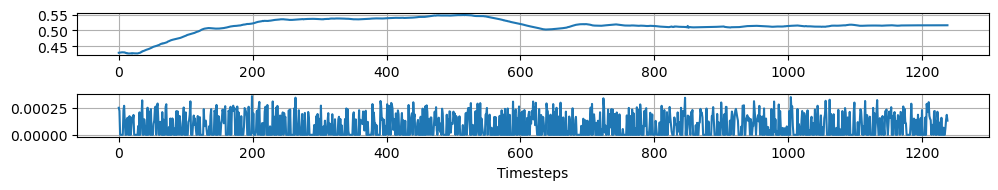

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(10, 2))

for ax in range(2):
    axs[ax].plot(timesteps, errors[:, ax], linestyle='-')
    axs[ax].grid(True)

axs[-1].set_xlabel('Timesteps')
plt.tight_layout()
plt.show()

In [37]:
tx_base_tcp[0][:3, 3] - pose_trajectory[0][:3, 3]

array([ 5.17303322e-09, -8.45095854e-09,  1.11140055e-08])

In [35]:
T_diff = np.linalg.inv(tx_base_tcp[0]) @ pose_trajectory[0]

In [36]:
T_diff[:3, 3]

array([ 0.0575539 , -0.39535807,  0.15572731])

In [38]:
tx_base_tcp[0][:3, :3]

array([[-0.99724304,  0.00628556,  0.07393826],
       [-0.0665739 ,  0.36432809, -0.92888802],
       [-0.03277637, -0.93124946, -0.3629052 ]])

In [39]:
pose_trajectory[0][:3, :3]

array([[-0.99724299,  0.00628552,  0.07393839],
       [-0.06657404,  0.36432809, -0.92888802],
       [-0.03277638, -0.93124944, -0.36290517]])

In [40]:
T_diff[:3, :3]

array([[ 9.99999962e-01,  3.69474974e-08, -1.32203879e-07],
       [-4.00696152e-08,  9.99999975e-01, -2.32318524e-08],
       [ 1.45297448e-07, -3.37779282e-09,  1.00000000e+00]])